In [1]:
import matplotlib.pyplot as plt
from torch import nn
from torch_geometric.loader import DataLoader
import torch
import numpy as np

from polymer_project.models.dimenet_latent import DimeNetPlusPlusLatent
from polymer_project.src.visualisation import plot_scatter
from polymer_project.src.prediction import predict_1d_target
from polymer_project.src.training_v_1 import train
from polymer_project.src.load_data import load_data_files, load_data_list
from sklearn.metrics import mean_absolute_error

In [2]:
import umap


def umap_2d(Z, n_neighbors=30, min_dist=0.1, metric="cosine", random_state=42):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    return reducer.fit(Z)

def plot_umap(U, xlim, ylim, fname, labels=None, title="UMAP(latent z)", s=2, alpha=0.6):
    plt.figure(figsize=(10, 10))

    if labels is None:
        plt.scatter(U[:, 0], U[:, 1], s=s, alpha=alpha)
        plt.title(title)
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.tight_layout()

        plt.xlim([-5,25])
        plt.ylim([-10,25])

        plt.show()
        return

    labels = np.asarray(labels)

    # --- Helpers ---
    z_to_symbol = {
        1: "H", 5: "B", 6: "C", 7: "N", 8: "O", 9: "F",
        14: "Si", 15: "P", 16: "S", 17: "Cl", 35: "Br", 53: "I",
        85: "At", 117: "Ts"
    }
    halogens = {"F", "Cl", "Br", "I", "At", "Ts"}

    def normalize_symbol(x):
        # numeric atomic number -> symbol
        if isinstance(x, (int, np.integer)):
            return z_to_symbol.get(int(x), str(int(x)))
        if isinstance(x, (float, np.floating)) and float(x).is_integer():
            return z_to_symbol.get(int(x), str(int(x)))

        # string-like -> normalized chemical symbol
        sx = str(x).strip()
        if not sx:
            return sx
        if sx.isdigit():
            return z_to_symbol.get(int(sx), sx)

        # e.g. "cl" -> "Cl", "BR" -> "Br"
        if len(sx) == 1:
            return sx.upper()
        return sx[0].upper() + sx[1:].lower()

    symbols = np.array([normalize_symbol(x) for x in labels], dtype=object)

    # --- Explicit categories ---
    mask_C = symbols == "C"
    mask_O = symbols == "O"
    mask_S = symbols == "S"
    mask_hal = np.isin(symbols, list(halogens))
    mask_other = ~(mask_C | mask_O | mask_S | mask_hal)

    # Plot others first (background)
    if np.any(mask_other):
        plt.scatter(
            U[mask_other, 0], U[mask_other, 1],
            s=s, alpha=0.20, c="lightgray", label="Other"
        )

    # Highlight key atom types
    if np.any(mask_C):
        plt.scatter(
            U[mask_C, 0], U[mask_C, 1],
            s=s, alpha=alpha, c="black", label="C (carbon)"
        )
    if np.any(mask_O):
        plt.scatter(
            U[mask_O, 0], U[mask_O, 1],
            s=s, alpha=alpha, c="red", label="O (oxygen)"
        )
    if np.any(mask_S):
        plt.scatter(
            U[mask_S, 0], U[mask_S, 1],
            s=s, alpha=alpha, c="gold", edgecolors="none", label="S (sulfur)"
        )
    if np.any(mask_hal):
        plt.scatter(
            U[mask_hal, 0], U[mask_hal, 1],
            s=s, alpha=alpha, c="limegreen", label="Halogens (F/Cl/Br/I/...)"
        )

    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(markerscale=3, frameon=True, loc="best")
    plt.tight_layout()

    plt.xlim(xlim)
    plt.ylim(ylim)

    plt.savefig(fname=fname, dpi=500, format='svg')

    plt.show()

In [3]:
def predict_1d_target(model, data_loaders: list):
    model.eval()
    prediction_arrays = []

    for data_loader in data_loaders:
        y_train_pred = []
        y_train_true = []

        emb_train_pred = []
        z_train_true = []

        with torch.no_grad():
            for batch in data_loader:
                batch = batch.to('cuda')
                outputs, emb, z = model(batch.x, batch.pos, batch.batch)
                y_train_pred.extend(outputs.cpu().numpy())
                y_train_true.extend(batch.y.cpu().numpy())

                emb_train_pred.extend(emb.cpu().numpy())
                z_train_true.extend(z.cpu().numpy())


            prediction_arrays.append((np.array(y_train_pred), np.array(y_train_true), np.array(emb_train_pred), np.array(z_train_true)))

    return prediction_arrays

In [4]:
target = 'lumo'

# Pretrain

In [5]:
directory_pretrain = r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project\data\NREL_opv\NREL_opv_dataset_DFT_geom_to_prop_dimenet_extrapol_filter_1-2.4'

data_pretrain = load_data_files(directory_pretrain, target=0, exclude_atom=1)

In [6]:
params = {
    'hidden_channels': 256,
    'out_channels': 1,
    'num_blocks': 4,
    'max_num_neighbors': 64,
    'int_emb_size': 64,
    'basis_emb_size': 8,
    'out_emb_channels': 256,
    'num_spherical': 4,
    'num_radial': 3,
    'output_initializer': 'zeros',
    'cutoff': 5,
    'envelope_exponent': 5,
    'num_before_skip': 1,
    'num_after_skip': 2,
    'num_output_layers': 4,
    'act': 'swish'
}

model_pretrain = DimeNetPlusPlusLatent(**params).to('cuda')
# model_pretrain = DimeNetPlusPlus(**params).to('cuda')

optimizer = torch.optim.AdamW(model_pretrain.parameters(), lr=0.0008, weight_decay=0.0, amsgrad=True)
loss_function = nn.MSELoss().to('cuda')

model_pretrain.load_state_dict(torch.load(fr'C:\Users\AI1-PC\PycharmProjects\main\polymer_project\models\extrapolation_based\DimeNet_NREL_{target}_pretrained_filter_1-2.4_v_1.pt'))

<All keys matched successfully>

In [7]:
from sklearn.preprocessing import QuantileTransformer, RobustScaler, PowerTransformer

train_data_list_pretrain, val_data_list_pretrain, test_data_list_pretrain = load_data_list(train_size=0.8, val_size=0.1, data_list=data_pretrain)

train_y_pretrain = torch.cat([data.y for data in train_data_list_pretrain]).numpy()

transform_function = PowerTransformer(method='box-cox')
# transform_function = RobustScaler()
train_y_pretrain_transformed = transform_function.fit_transform(train_y_pretrain.reshape(-1, 1))

def apply_transform(data_list, transformer):
    for data in data_list:
        y_numpy = data.y.numpy()
        y_transformed = transformer.transform(y_numpy.reshape(-1, 1))
        data.y = torch.tensor(y_transformed, dtype=torch.float32)

apply_transform(train_data_list_pretrain, transform_function)
apply_transform(val_data_list_pretrain, transform_function)
apply_transform(test_data_list_pretrain, transform_function)

train_loader_pretrain = DataLoader(train_data_list_pretrain, batch_size=100, shuffle=True, pin_memory=True, num_workers=0)
val_loader_pretrain = DataLoader(val_data_list_pretrain, batch_size=100, shuffle=False, pin_memory=True, num_workers=0)
test_loader_pretrain = DataLoader(test_data_list_pretrain, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)

In [ ]:
torch.cuda.empty_cache()

# Fine-tuning

In [8]:
params = {
    'hidden_channels': 256,
    'out_channels': 1,
    'num_blocks': 4,
    'max_num_neighbors': 64,
    'int_emb_size': 64,
    'basis_emb_size': 8,
    'out_emb_channels': 256,
    'num_spherical': 4,
    'num_radial': 3,
    'output_initializer': 'zeros',
    'cutoff': 3.5,
    'envelope_exponent': 5,
    'num_before_skip': 1,
    'num_after_skip': 2,
    'num_output_layers': 4,
    'act': 'swish'
}

model_fine = DimeNetPlusPlusLatent(**params).to('cuda')

loss_function = nn.MSELoss().to('cuda')
# loss_function = nn.HuberLoss().to('cuda')

model_fine.load_state_dict(torch.load(fr'C:\Users\AI1-PC\PycharmProjects\main\polymer_project\models\extrapolation_based\DimeNet_NREL_{target}_extrapol_filter_1-2.4_v_1.pt'))

<All keys matched successfully>

In [9]:
directory_fine_tune = r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project\data\polymers\poly_v_2_graph_geom_to_prop_Hs_dimenet'

data_fine_tune = load_data_files(directory_fine_tune, target=0, exclude_atom=1)

In [10]:
train_data_list_fine_tune, val_data_list_fine_tune, test_data_list_fine_tune = load_data_list(train_size=0.8, val_size=0.1, data_list=data_fine_tune)

train_y_fine_tune = torch.cat([data.y for data in train_data_list_fine_tune]).numpy()

train_y_fine_tune_transformed = transform_function.transform(train_y_fine_tune.reshape(-1, 1))

apply_transform(train_data_list_fine_tune, transform_function)
apply_transform(val_data_list_fine_tune, transform_function)
apply_transform(test_data_list_fine_tune, transform_function)

train_loader_fine_tune = DataLoader(train_data_list_fine_tune, batch_size=150, shuffle=True, pin_memory=False, num_workers=0)
val_loader_fine_tune = DataLoader(val_data_list_fine_tune, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)
test_loader_fine_tune = DataLoader(test_data_list_fine_tune, batch_size=100, shuffle=False, pin_memory=False, num_workers=0)

In [21]:
torch.cuda.empty_cache()

In [ ]:
# torch.save(model.state_dict(), r'C:\Users\AI1-PC\PycharmProjects\main\polymer_project\models\trained_models\DimeNet_NREL_homo_extrapol_filter_1-2.4_v_1.pt')

# Prediction

In [11]:
prediction_fine_tune = predict_1d_target(model_fine, data_loaders=[train_loader_fine_tune, val_loader_fine_tune, test_loader_fine_tune])

_, _, emb_train_fine, z_train_fine = prediction_fine_tune[0]

_, _, emb_test_fine, z_test_fine = prediction_fine_tune[1]

# def predict_1d_target(model, data_loaders: list):
#     model.eval()
#     prediction_arrays = []
#
#     for data_loader in data_loaders:
#         E_train_pred = []
#         E_train_true = []
#
#         emb_list = []
#         z_list = []
#
#
#         with torch.no_grad():
#             for batch in data_loader:
#                 batch = batch.to('cuda')
#                 E = model(batch.x, batch.pos, batch.batch)
#                 E_train_pred.extend(E.cpu().numpy())
#                 E_train_true.extend(batch.y.cpu().numpy())
#
#             prediction_arrays.append((np.array(E_train_pred), np.array(E_train_true)))
#
#     return prediction_arrays
#
# prediction_fine_tune = predict_1d_target(model_pretrain, data_loaders=[train_loader_fine_tune, val_loader_fine_tune, test_loader_fine_tune])
#
# y_train_pred_fine_tune, y_train_true_fine_tune = prediction_fine_tune[0]
#
# y_test_pred_fine_tune, y_test_true_fine_tune = prediction_fine_tune[1]

In [12]:
prediction_pretrain = predict_1d_target(model_pretrain, data_loaders=[train_loader_fine_tune, val_loader_fine_tune, test_loader_fine_tune])

_, _, emb_train_pretrain, z_train_pretrain = prediction_pretrain[0]

_, _, emb_test_pretrain, z_test_pretrain = prediction_pretrain[1]

In [13]:
UMAP_fitted_eu_pretrain_test = umap_2d(emb_test_pretrain, n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=None)

C:\Users\AI1-PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [14]:
UMAP_fitted_cos_pretrain_test = umap_2d(emb_test_pretrain, n_neighbors=30, min_dist=0.1, metric="cosine", random_state=None)

C:\Users\AI1-PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [15]:
UMAP_transform_eu_pretrain_test = UMAP_fitted_eu_pretrain_test.transform(emb_test_pretrain)
UMAP_transform_eu_fine_test = UMAP_fitted_eu_pretrain_test.transform(emb_test_fine)

UMAP_transform_cos_pretrain_test = UMAP_fitted_cos_pretrain_test.transform(emb_test_pretrain)
UMAP_transform_cos_fine_test = UMAP_fitted_cos_pretrain_test.transform(emb_test_fine)

C:\Users\AI1-PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\AI1-PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\AI1-PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\AI1-PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [34]:
np.savetxt(f'raw_data/{target}/model_{target}_dft_pretrain_data_test_exp_euclidean.csv', np.concatenate((UMAP_transform_eu_pretrain_test,z_test_pretrain.reshape(-1,1)), axis=1), delimiter=',')
np.savetxt(f'raw_data/{target}/model_{target}_exp_fine_tuned_data_test_exp_euclidean.csv', np.concatenate((UMAP_transform_eu_fine_test,z_test_pretrain.reshape(-1,1)), axis=1), delimiter=',')
np.savetxt(f'raw_data/{target}/model_{target}_dft_pretrain_data_test_exp_cosine.csv', np.concatenate((UMAP_transform_cos_pretrain_test,z_test_pretrain.reshape(-1,1)), axis=1), delimiter=',')
np.savetxt(f'raw_data/{target}/model_{target}_exp_fine_tuned_data_test_exp_cosine.csv', np.concatenate((UMAP_transform_cos_fine_test,z_test_pretrain.reshape(-1,1)), axis=1), delimiter=',')

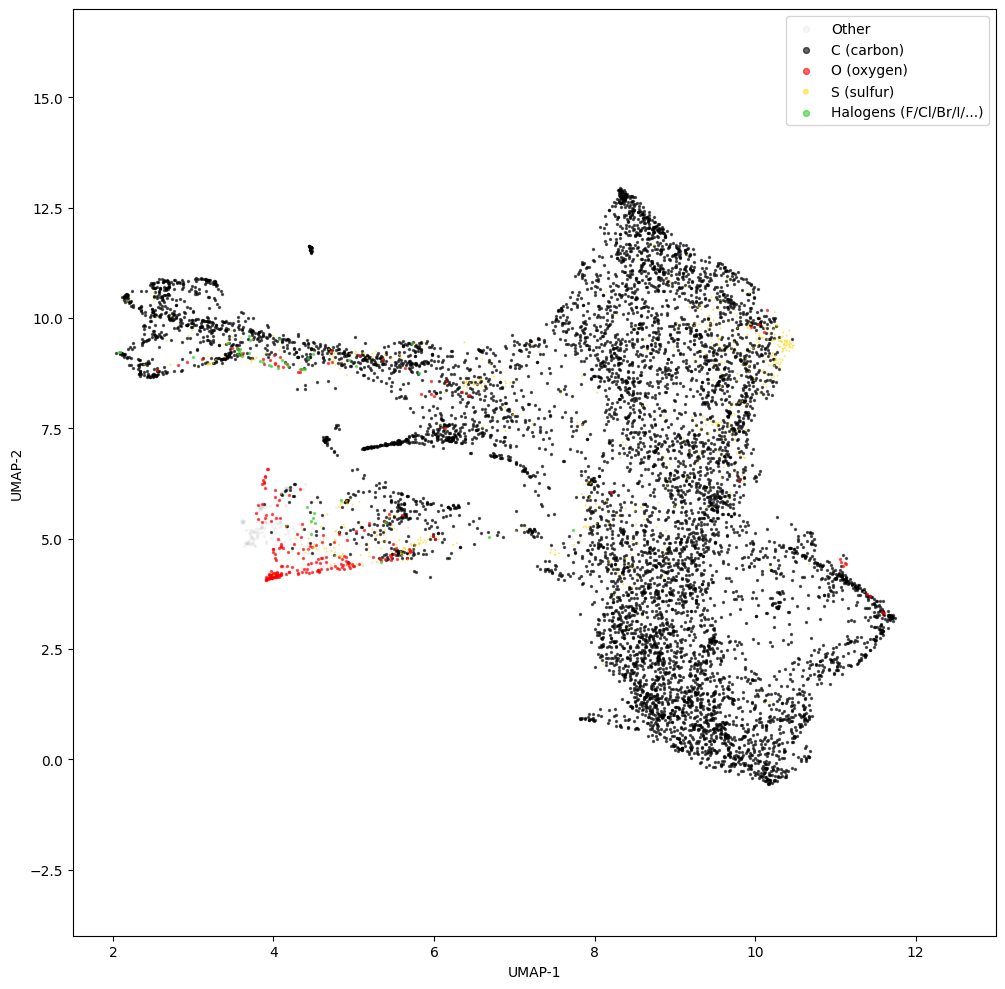

In [23]:
plot_umap(UMAP_transform_eu_pretrain_test, labels=z_test_pretrain, title='',xlim=[1.5,13], ylim=[-4,17], fname=f'raw_data/{target}/model_{target}_dft_pretrain_data_test_exp_euclidean.svg')

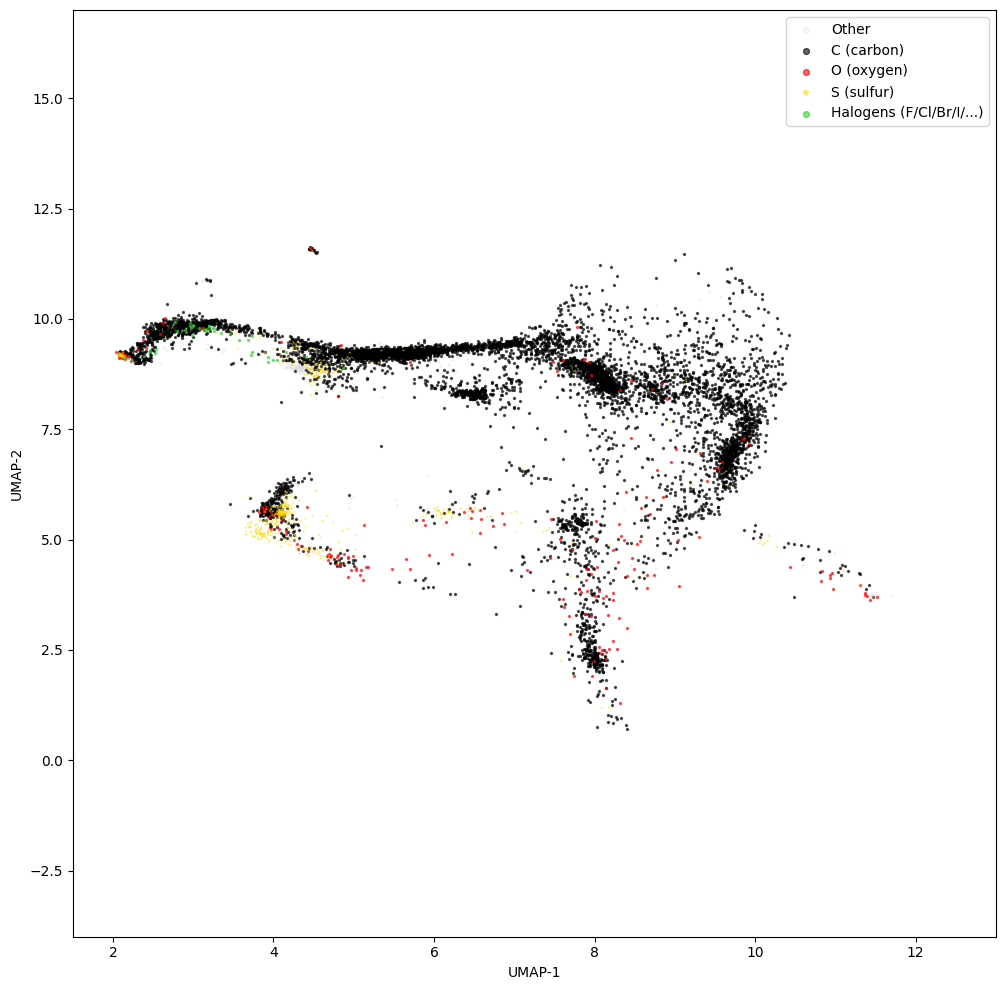

In [24]:
plot_umap(UMAP_transform_eu_fine_test, labels=z_test_fine, title='',xlim=[1.5,13], ylim=[-4,17], fname=f'raw_data/{target}/model_{target}_exp_fine_tuned_data_test_exp_euclidean.svg')

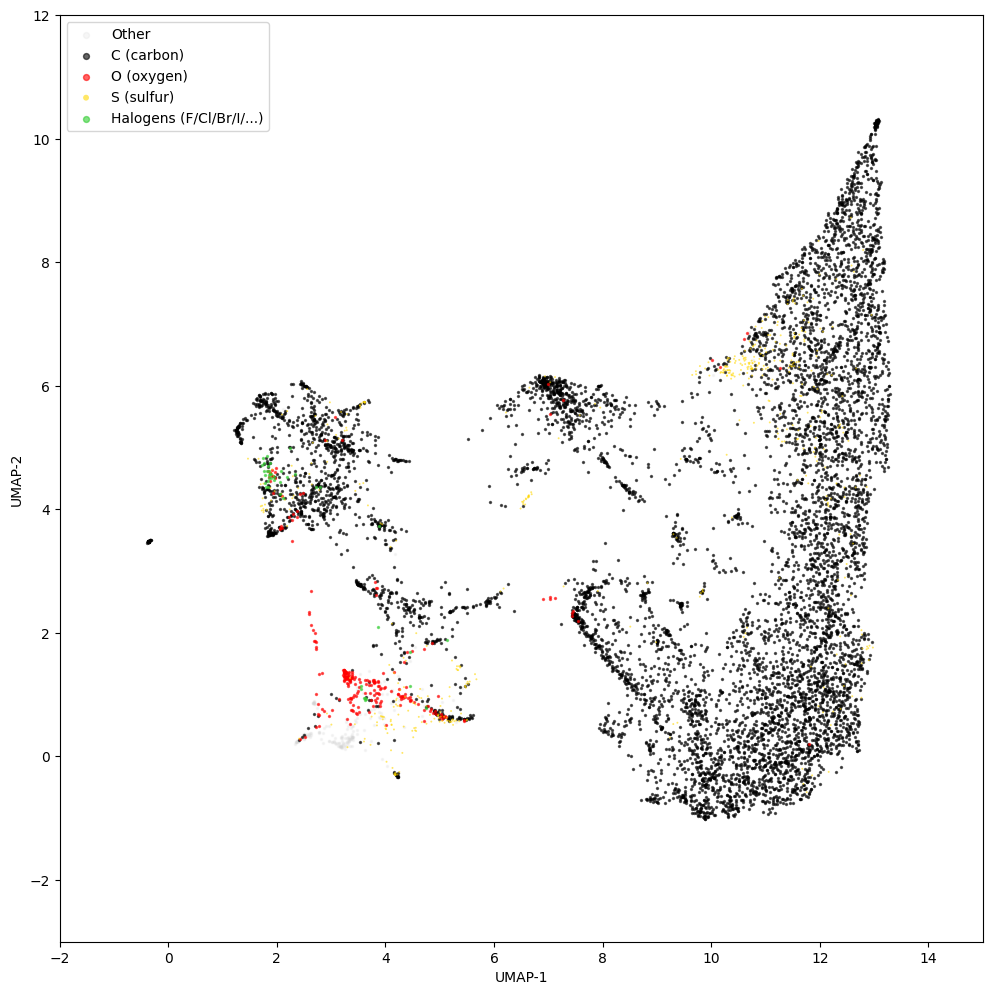

In [32]:
plot_umap(UMAP_transform_cos_pretrain_test, labels=z_test_pretrain, title='',xlim=[-2,15], ylim=[-3,12], fname=f'raw_data/{target}/model_{target}_dft_pretrain_data_test_exp_cosine.svg')

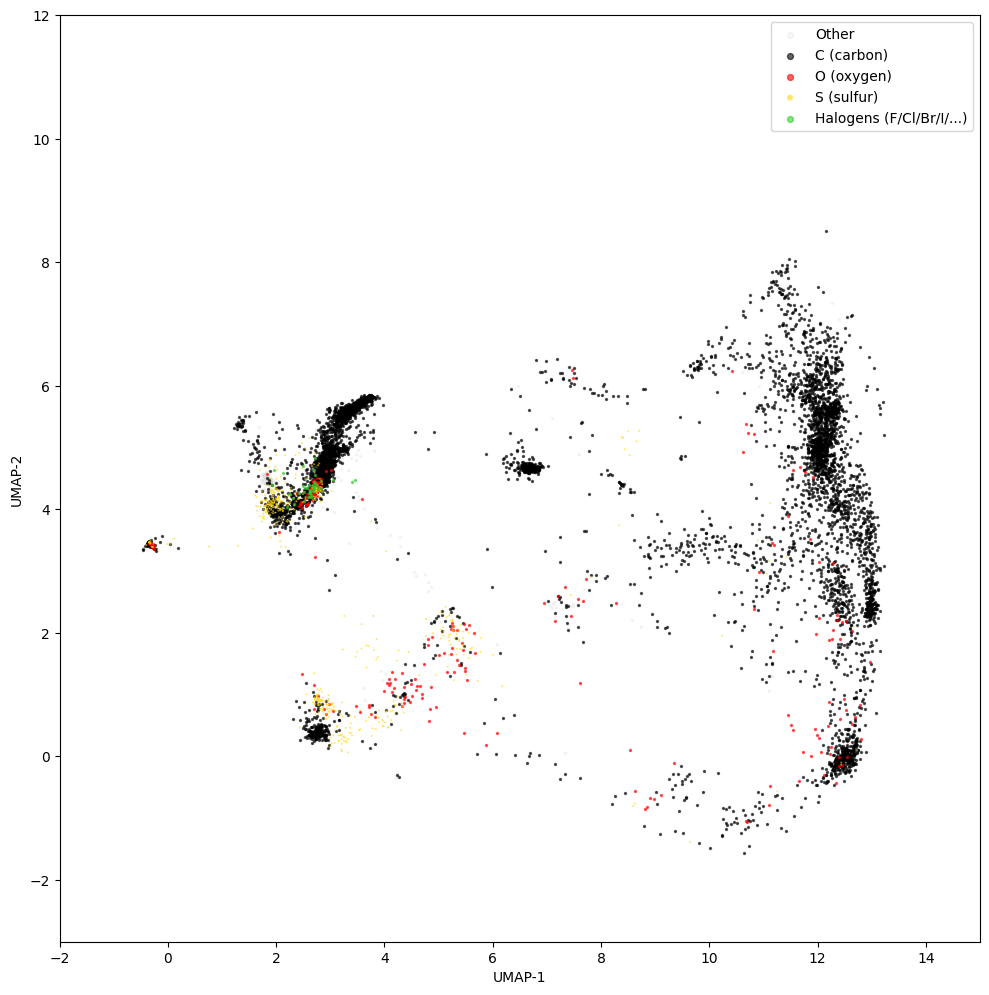

In [33]:
plot_umap(UMAP_transform_cos_fine_test, labels=z_test_fine, title='',xlim=[-2,15], ylim=[-3,12], fname=f'raw_data/{target}/model_{target}_exp_fine_tuned_data_test_exp_cosine.svg')